In [1]:
import os
import qsprpred

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
os.makedirs("dataset_outputs/A2AR/data", exist_ok=True)

# Create dataset
dataset = QSPRDataset.fromTableFile(
    filename="data/src/datasets/a2ar/data/A2AR.csv",
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
)

In [3]:
dataset.getDF().Y.sum()

3932

In [4]:
dataset.prepareDataset(
    split=RandomSplit(test_fraction=0.2, dataset=dataset),
    feature_calculators=[MorganFP(radius=2, nBits=4096)],
    recalculate_features=True,
)

In [5]:
from qsprpred.data.descriptors.sets import RDKitDescs

rdkit_descs = RDKitDescs()

dataset.addDescriptors([rdkit_descs])

dataset.descriptorSets

In [6]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [7]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import pandas as pd
def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    return my_df

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = dataset.X
X1, X2, y1, y2 = train_test_split(dataset.X, dataset.y, test_size=0.25, random_state=42)
X3 = dataset.X_ind
y3 = dataset.y_ind

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)

scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)



In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))


,0,1,2,3,4,5,6,7,8,9,...,4296,4297,4298,4299,4300,4301,4302,4303,4304,4305
0,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,1.980336
1,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,2.943564,-0.181096,-0.225319,-0.258817
2,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.213839
3,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,1.331313
4,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,4.222915,-2.480443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3533,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,1.656237,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.403167
3534,-0.040456,0.0,-0.099504,-0.020215,-0.070186,10.614778,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,2.308674,1.306710
3535,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,1.656237,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.168575
3536,-0.040456,0.0,-0.099504,-0.020215,-0.070186,-0.053551,-0.067184,-0.603779,-0.111386,0.0,...,-0.145865,-0.060746,-0.088443,-0.116896,-0.359386,0.0,-0.281971,-0.181096,-0.225319,0.589209


In [12]:
test_par = {'weight_decay': 0.0001, 'patience': 75, 
            'neuron_layers':[1024, 512, 256, 128, 64, 32, 16, 8, 4],
            'n_epochs': 200, 'dropout_frac': 0.5,
            'act_fun': F.selu,
           "tol": 1e-5}
model_sts_3 = STFullyConnected(n_dim=X1.shape[1],  # počet vstupních neuronů (počet deskriptorů)
    n_class=1,  # regresní úloha (1 výstup)
    gpus=[],
    device="cuda",
    batch_size=256,is_reg=False, **test_par)
model_sts_3.fit(X1, y1)
res = model_sts_3.predict(X2)
res = res >0.5
print(f1_score(res, y2))

0.9811083123425692


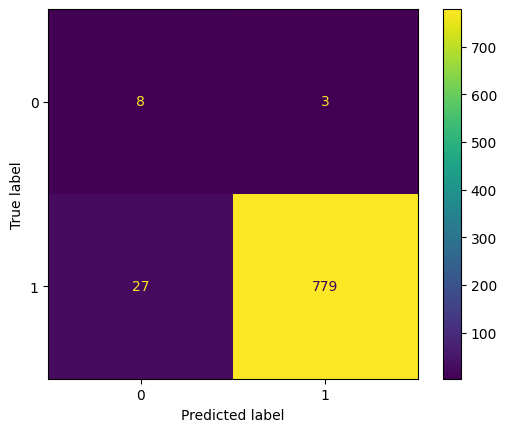

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_mat = confusion_matrix(res, y2)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat)
disp.plot()

In [11]:
from torch import optim
import torch
my_dict_ult = {
    "act_fun": [F.selu],
    "dropout_frac": [0.1, 0.4, 0.5, 0.6],
    "patience": [75],
    "tol": [1e-5],
    "weight_decay": [1e-4, 1e-3, 1e-5],
    "n_epochs": [200,300, 400],
    "neuron_layers": [[ 5000, 2500], [ 1024, 512, 256, 128, 64, 32, 16, 8, 4],  [2048, 1024, 512, 256, 128], [4096, 2048], [7500, 3750]]
    , "batch_size": [256]
    , "optimizer": [optim.AdamW] 
}
df_batch_ult = test_fun(my_dict_ult, X1, y1, X2, y2)

Device used: cuda
1 / 180
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9755469755469756
0.9534883720930233
2 / 180
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.001}
0.9755469755469756
0.9534883720930233
3 / 180
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'n_epochs': 200, 'neuron_layers': [5000, 2500], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 1e-05}
0.9755469755469756
0.9534883720930233
4 / 180
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'n_epochs': 200, 'neuron_layers': [1024,

KeyboardInterrupt: 

In [ ]:
# {'act_fun': <function selu at 0x7f99fa88b240>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 200, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4],
#'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.001}

In [ ]:
from torch import optim
import torch
my_dict_ult_2 = {
    "act_fun": [F.selu],
    "dropout_frac": [ 0.45, 0.5, 0.55],
    "patience": [75],
    "tol": [1e-5],
    "weight_decay": [1e-4],
    "n_epochs": [150, 200,250],
    "neuron_layers": [[ 2048, 1024, 512, 256, 128, 64, 32, 16, 8], [ 1024, 512, 256, 128, 64, 32, 16, 8, 4],   [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]]
    , "batch_size": [256, 512, 128]
    , "optimizer": [optim.AdamW, optim.Adagrad, optim.RMSprop] 
}
df_batch_ult_2 = test_fun(my_dict_ult_2, X1, y1, X2, y2) 
{'act_fun': <function selu at 0x7f99fa88b240>, 'batch_size': 128, 'dropout_frac': 0.55, 'n_epochs': 200, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9810606060606061
0.9632802937576499
{'act_fun': <function selu at 0x7f99fa88b240>, 'batch_size': 128, 'dropout_frac': 0.5, 'n_epochs': 200, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9802924348378894
0.9620563035495716

In [12]:
from torch import optim
import torch
#{'act_fun': <function selu at 0x7f99fa88b240>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 300, 
#'neuron_layers': [2048, 1024, 512, 256, 128], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.001}
0.9794344473007712
my_dict_ult_4 = {
    "act_fun": [F.selu, F.gelu, F.elu],
    "dropout_frac": [0.5, 0.55, 0.45],
    "patience": [75],
    "tol": [1e-5],
    "weight_decay": [1e-4],
    "n_epochs": [150, 200, 250],
    "neuron_layers": [[1024, 512, 256, 128, 64, 32, 16, 8, 4]]
    , "batch_size": [256, 128, 64]
    , "optimizer": [optim.AdamW, optim.RMSprop] 
}
df_batch_ult_4 = test_fun(my_dict_ult_4, X1, y1, X2, y2)

Device used: cuda
1 / 162
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 150, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9793362554790231
0.9596083231334149
2 / 162
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 150, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9804416403785489
0.9620563035495716
3 / 162
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.5, 'n_epochs': 200, 'neuron_layers': [1024, 512, 256, 128, 64, 32, 16, 8, 4], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9811083123425692
0.9632802937576499
4 / 162
{'act_fun': <function selu at 0x7f301633

In [13]:
df_batch_ult_4.sort_values(by="F1", ascending=False, inplace=True)

In [14]:
df_batch_ult_4.to_csv('qsprpred/extra/gpu/models/dataset_outputs/A2AR/tabs/A2ARbatch2.csv')

In [15]:
df_batch_ult_4

,act_fun,batch_size,dropout_frac,n_epochs,neuron_layers,optimizer,patience,tol,weight_decay,F1,Acc
2,<function selu at 0x7f3016337060>,256,0.50,200,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.adamw.AdamW'>,75,0.00001,0.0001,0.981108,0.963280
146,<function elu at 0x7f3016336fc0>,64,0.50,200,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.adamw.AdamW'>,75,0.00001,0.0001,0.981084,0.963280
27,<function selu at 0x7f3016337060>,128,0.55,200,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.981061,0.963280
147,<function elu at 0x7f3016336fc0>,64,0.50,200,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.980989,0.963280
43,<function selu at 0x7f3016337060>,64,0.55,150,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.980466,0.962056
...,...,...,...,...,...,...,...,...,...,...,...
53,<function selu at 0x7f3016337060>,64,0.45,250,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.954967,0.916769
35,<function selu at 0x7f3016337060>,128,0.45,250,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.951559,0.910649
41,<function selu at 0x7f3016337060>,64,0.50,250,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.950798,0.909425
49,<function selu at 0x7f3016337060>,64,0.45,150,"[1024, 512, 256, 128, 64, 32, 16, 8, 4]",<class 'torch.optim.rmsprop.RMSprop'>,75,0.00001,0.0001,0.950100,0.908201


In [ ]:
my_dict_ult_5 = {
    "act_fun": [F.selu],
    "dropout_frac": [ 0.1, 0.25, 0.4, 0.55, 0.7],
    "patience": [75],
    "tol": [1e-5],
    "weight_decay": [1e-4],
    "n_epochs": [200, 400, 600, 800],
    "neuron_layers": [[4096, 2048, 2048, 512, 128],   [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8], [7500, 2500], [5000]]
    , "batch_size": [256, 512, 128]
    , "optimizer": [optim.AdamW, optim.RMSprop],
    "lr": [1e-4, 1e-3, 1e-5]
}
df_batch_ult_5 = test_fun(my_dict_ult_5, X1, y1, X2, y2) 

Device used: cuda
1 / 1440
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 2048, 512, 128], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9627694317439582
0.9302325581395349
2 / 1440
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 2048, 512, 128], 'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9675745784695201
0.9388004895960832
3 / 1440
{'act_fun': <function selu at 0x7f3016337060>, 'batch_size': 256, 'dropout_frac': 0.1, 'lr': 0.0001, 'n_epochs': 200, 'neuron_layers': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8], 'optimizer': <class 'torch.optim.adamw.AdamW'>, 'patience': 75, 'tol': 1e-05, 'weight_decay': 0.0001}
0.9170068027210885
0.8506731946144431
4 / 1440
{'act_f

In [ ]:
df_batch_ult_5.sort_values(by="F1", ascending=False, inplace=True)
df_batch_ult_5.to_csv('qsprpred/extra/gpu/models/dataset_outputs/A2AR/tabs/A2ARbatch5.csv')